# Plant Whisper AI — MobileNetV2 with Manual Class Weights


In [4]:
import os
import shutil
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Train/Test split with grouping to avoid augmentation leakage

In [5]:
SOURCE_DIR = "/content/drive/MyDrive/Plant_Whisper_AI/processed_dataset_augmented"  # UNBALANCED source — let class_weight handle the imbalance instead of synthetic balancing
OUT_DIR = "/content/dataset_split"  # local Colab disk — Drive can be read-only/slow for many small file copies
CLASSES = ["Cut", "Dry"]
TEST_SIZE = 0.2
SEED = 42

def get_group_id(filename):
    # Strips _augN / _vN suffixes so all variants of one source recording
    # land in the same split (train OR test, never both).
    return re.sub(r'(_aug\d+|_v\d+)?\.\w+$', '', filename)

# Only rebuild the split if it doesn't already exist, so re-running the
# notebook doesn't reshuffle files that are already split.
if not os.path.exists(OUT_DIR):
    for cls in CLASSES:
        files = os.listdir(os.path.join(SOURCE_DIR, cls))
        groups = sorted(set(get_group_id(f) for f in files))

        train_groups, test_groups = train_test_split(
            groups, test_size=TEST_SIZE, random_state=SEED
        )

        for split_name, split_groups in [("train", train_groups), ("test", test_groups)]:
            out_path = os.path.join(OUT_DIR, split_name, cls)
            os.makedirs(out_path, exist_ok=True)
            for f in files:
                if get_group_id(f) in split_groups:
                    shutil.copy(
                        os.path.join(SOURCE_DIR, cls, f),
                        os.path.join(out_path, f)
                    )

        print(f"{cls}: {len(train_groups)} train groups, {len(test_groups)} test groups")
else:
    print(f"{OUT_DIR} already exists — skipping split (delete it first to rebuild).")

Cut: 2640 train groups, 660 test groups
Dry: 6488 train groups, 1622 test groups


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data generators

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.05,
    zoom_range=0.05
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(OUT_DIR, "train"),
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(OUT_DIR, "test"),
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # keep order aligned with .classes for evaluation later
)

print("Class indices:", train_generator.class_indices)

Found 9128 images belonging to 2 classes.
Found 2282 images belonging to 2 classes.
Class indices: {'Cut': 0, 'Dry': 1}


## 3. Manual class weights — lighter correction than auto 'balanced' (1.73/0.70)

In [8]:
# NOTE: this assumes Cut=0, Dry=1 per the class_indices above.
# If it's reversed, swap which key gets 1.3 vs 0.85.
class_weight_dict = {0: 1.3, 1: 0.85}
print("Class weights:", class_weight_dict)

Class weights: {0: 1.3, 1: 0.85}


## 4. Build model — MobileNetV2, frozen base

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',  # default LR = 1e-3
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 5. Phase 1 — train classifier head only

In [10]:
print("--- Phase 1: Training classifier head (base frozen) ---")
print("Base trainable:", base_model.trainable)
print("Optimizer LR:", model.optimizer.learning_rate.numpy())

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

model.save("/content/drive/MyDrive/Plant_Whisper_AI/manual_weights_phase1.keras")
print("Saved manual_weights_phase1.keras to Drive")

--- Phase 1: Training classifier head (base frozen) ---
Base trainable: False
Optimizer LR: 0.001
Epoch 1/40
286/286 ━━━━━━━━━━━━━━━━━━━━ 106s 295ms/step - accuracy: 0.6936 - loss: 0.6446 - val_accuracy: 0.6678 - val_loss: 0.6219 - learning_rate: 0.0010
Epoch 2/40
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - accuracy: 0.7213 - loss: 0.6101 - val_accuracy: 0.7213 - val_loss: 0.5811 - learning_rate: 0.0010
Epoch 3/40
286/286 ━━━━━━━━━━━━━━━━━━━━ 57s 198ms/step - accuracy: 0.7145 - loss: 0.6078 - val_accuracy: 0.7217 - val_loss: 0.5861 - learning_rate: 0.0010
Epoch 4/40
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - accuracy: 0.7222 - loss: 0.5941 - val_accuracy: 0.7458 - val_loss: 0.5545 - learning_rate: 0.0010
Epoch 5/40
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 197ms/step - accuracy: 0.7171 - loss: 0.5989 - val_accuracy: 0.7209 - val_loss: 0.5804 - learning_rate: 0.0010
Epoch 6/40
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 196ms/step - accuracy: 0.7215 - loss: 0.5896 - val_accuracy: 0.7362 - val_loss: 0.

OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/Plant_Whisper_AI/manual_weights_phase1.keras'

## 6. Phase 2 — fine-tune top layers (BatchNorm kept frozen)

In [11]:
print("--- Phase 2: Fine-tuning top layers ---")
base_model.trainable = True

# Unfreeze only the last 15 layers — keep the rest frozen
for layer in base_model.layers[:-15]:
    layer.trainable = False

# Critical fix: keep ALL BatchNorm layers frozen even in the unfrozen region,
# otherwise their running stats destabilize on a small dataset.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

model.save("/content/drive/MyDrive/Plant_Whisper_AI/manual_weights_phase2_finetuned.keras")
print("Saved manual_weights_phase2_finetuned.keras to Drive")

--- Phase 2: Fine-tuning top layers ---
Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 81s 243ms/step - accuracy: 0.7249 - loss: 0.5924 - val_accuracy: 0.7463 - val_loss: 0.5494 - learning_rate: 5.0000e-06
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 62s 215ms/step - accuracy: 0.7316 - loss: 0.5802 - val_accuracy: 0.7038 - val_loss: 0.5883 - learning_rate: 5.0000e-06
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 198ms/step - accuracy: 0.7261 - loss: 0.5798 - val_accuracy: 0.7336 - val_loss: 0.5535 - learning_rate: 5.0000e-06
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 197ms/step - accuracy: 0.7283 - loss: 0.5762 - val_accuracy: 0.7493 - val_loss: 0.5455 - learning_rate: 2.5000e-06
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 56s 195ms/step - accuracy: 0.7361 - loss: 0.5718 - val_accuracy: 0.7406 - val_loss: 0.5442 - learning_rate: 2.5000e-06
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 61s 212ms/step - accuracy: 0.7303 - loss: 0.5739 - val_accuracy: 0.7384 - val_loss: 0.5454 - learning_rate: 2.5000e-06
Epoch 

OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/Plant_Whisper_AI/manual_weights_phase2_finetuned.keras'

## 7. Evaluation — confusion matrix + classification report

72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step
[[ 335  325]
 [ 267 1355]]
              precision    recall  f1-score   support

         Cut       0.56      0.51      0.53       660
         Dry       0.81      0.84      0.82      1622

    accuracy                           0.74      2282
   macro avg       0.68      0.67      0.68      2282
weighted avg       0.73      0.74      0.74      2282

Drive was read-only — saved locally instead to /content/confusion_matrix_manual_weights.png


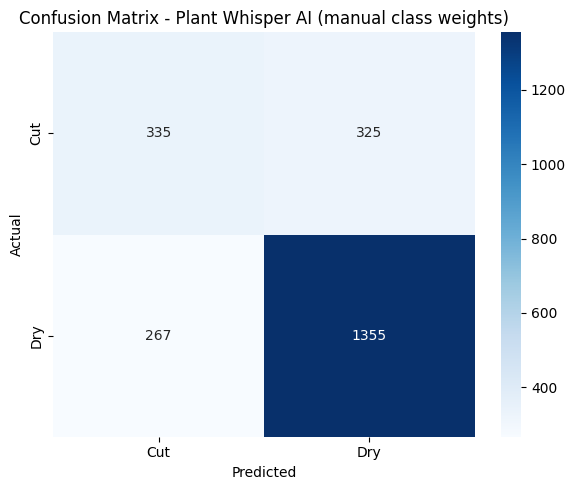

In [12]:
test_generator.reset()
preds = model.predict(test_generator)
y_pred = (preds > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

print(cm)
print(classification_report(y_true, y_pred, target_names=class_names))

# Save confusion matrix as an image
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    cbar=True
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Plant Whisper AI (manual class weights)')
plt.tight_layout()

cm_path = "/content/drive/MyDrive/Plant_Whisper_AI/confusion_matrix_manual_weights.png"
try:
    plt.savefig(cm_path, dpi=200)
    print(f"Saved confusion matrix image to {cm_path}")
except OSError:
    local_path = "/content/confusion_matrix_manual_weights.png"
    plt.savefig(local_path, dpi=200)
    print(f"Drive was read-only — saved locally instead to {local_path}")

plt.show()